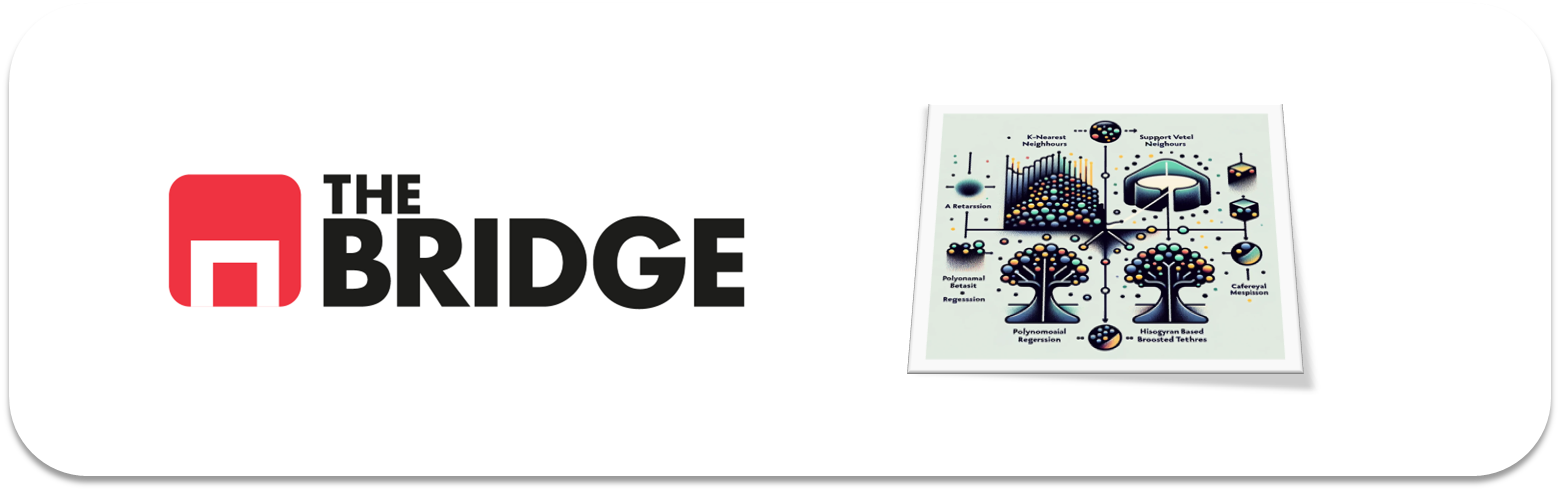

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE # Nuevos amigos para ayudaros
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVR

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



In [ ]:
df_init = pd.read_csv("./data/wines_dataset.csv", sep= "|")
df_init.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [ ]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
df_init.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4898
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,NaN
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,NaN
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,NaN
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,NaN
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,NaN
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,NaN


Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

In [ ]:
target_clasificacion = 'quality'
target_regresion = 'alcohol'

In [ ]:
df_init['class'].value_counts() # aplicaremos onehotencodign para categorizarla en integers

class
white    4898
red      1599
Name: count, dtype: int64

In [ ]:
df = df_init.copy()

MINI-EDA primer plroblema   

C:\Users\m_fon\AppData\Local\Temp\ipykernel_21332\1298620451.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


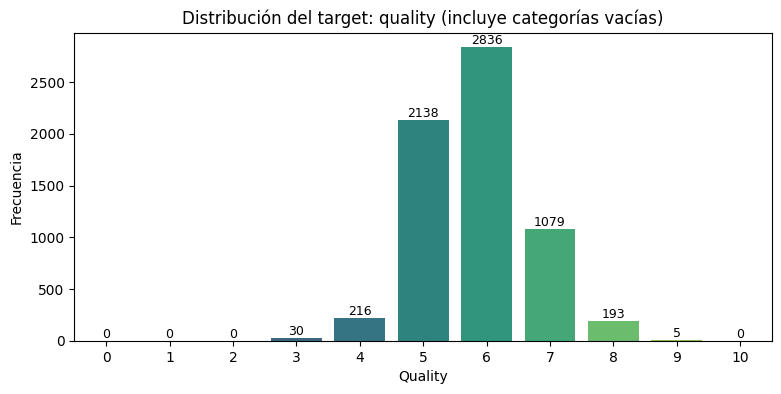

In [ ]:

# Definir todas las categorías posibles
all_categories = list(range(0, 11))   # 0 a 10

# Contar las categorías reales
counts = df["quality"].value_counts().sort_index()

# Crear un DataFrame que incluya también las categorías vacías
counts_full = pd.Series(0, index=all_categories)
counts_full.update(counts)

# Convertir a DataFrame para seaborn
df_plot = counts_full.reset_index()
df_plot.columns = ["quality", "count"]

plt.figure(figsize=(9,4))
ax = sns.barplot(
    data=df_plot,
    x="quality",
    y="count",
    palette="viridis"
)

plt.title("Distribución del target: quality (incluye categorías vacías)")
plt.xlabel("Quality")
plt.ylabel("Frecuencia")

# Etiquetas encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.0f}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=9
    )

plt.show()

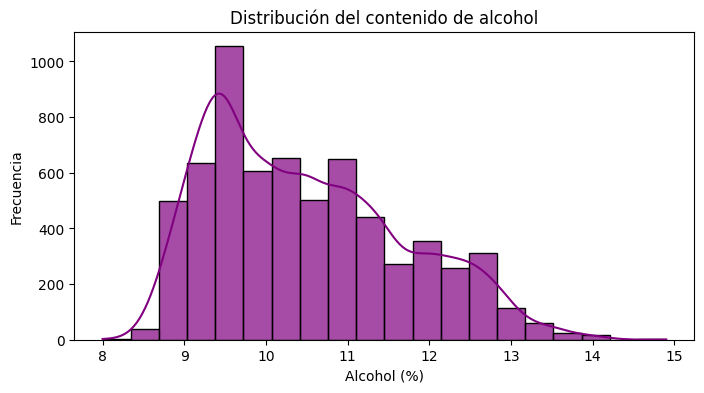

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["alcohol"],
    bins=20,
    kde=True,
    color="purple",
    edgecolor="black",
    alpha=0.7
)

plt.title("Distribución del contenido de alcohol")
plt.xlabel("Alcohol (%)")
plt.ylabel("Frecuencia")

plt.show()

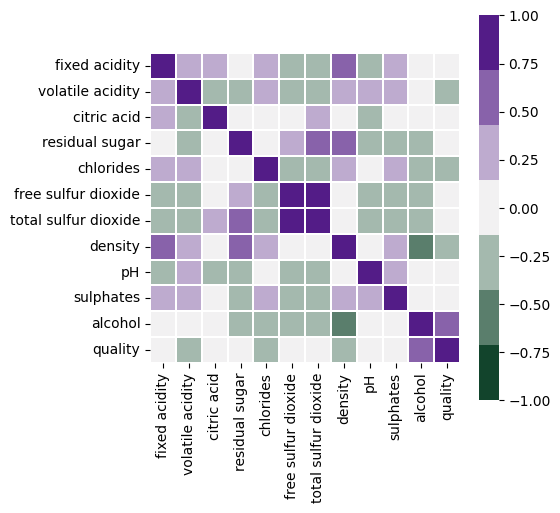

In [ ]:
matriz_corr = df.corr(numeric_only= True)
plt.figure(figsize=(5,5))
sns.heatmap(matriz_corr,
            vmin=-1,
            vmax=1,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
            square=True,
            linewidths=.1,
            annot=False);



hay fuerte correlación entre el dióxido de sulfuro libre y el total de sulfuro, nos quedaremos con la segunda por tener implicación en el sabor y que es consecuencia de la primera
También hay  cierta correlación entre densidad con acidez fija y densidad con azúcar residual. Eliminamos densidad por ser consecuencia de las otras ods
En definitiva descartamos 
features_to_remove = ['density', 'free sulfur dioxide']


In [ ]:
features_to_remove = ['density', 'free sulfur dioxide']
df = df.drop(columns=features_to_remove)
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,142.0,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,107.0,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,111.0,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,440.0,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,91.0,3.26,0.58,9.8,6,red



El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).


El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

## SPLIT Y onehotencoding de class PARA PROBLEMA DE CLASIFICACIÓN

In [ ]:
df_clasificacion = df.copy()

In [ ]:
X = df_clasificacion.drop(columns=['quality'])
y = df_clasificacion['quality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_train = encoder.fit_transform(X_train[['class']])  # fit + transform
ohe_test  = encoder.transform(X_test[['class']])  

In [ ]:
ohe_cols = encoder.get_feature_names_out(['class'])

X_train = pd.concat([
    X_train.drop(columns=['class']),
    pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
], axis=1)

X_test = pd.concat([
    X_test.drop(columns=['class']),
    pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)
], axis=1)

ESCALADMOS

In [ ]:
X_train.columns

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

### KNN BASELINE

In [ ]:

k_values = [3, 7]   
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    recall = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall_macro')
    print(f"K={k} → Recall medio: {recall.mean():.4f}")


## LOGISTIC REGRESSION Y RANDOM FOREST

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(),
}

for name, model in models.items():
    recall = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='recall_macro')
    print(f"{name} → Recall medio: {recall.mean():.4f}")

MEJORA DEL RECALL MEDIO USANDO class_weight = 'balanced'

In [ ]:
models_balanced = {
    "Logistic Regression (balanced)": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "Random Forest (balanced)": RandomForestClassifier(class_weight='balanced'),
}

for name, model in models_balanced.items():
    recall = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='recall_macro')
    print(f"{name} → Recall medio: {recall.mean():.4f}")

hay yna ligera mejora en el caso de Logistic Regressión

 OPTIMIZACIÓN DE HIPERPARÁMETROS en RANDOM FOREST recall medio balanced = 0.336

In [ ]:


param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"]
}
rf = RandomForestClassifier()
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

In [ ]:


best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

## SPLIT Y onehotencoding de class PARA PROBLEMA DE REGRESIÓN

In [ ]:
df_regression = df.copy()

In [ ]:
X = df_regression.drop(columns=['alcohol'])
y = df_regression['alcohol']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_train = encoder.fit_transform(X_train[['class']])  # fit + transform
ohe_test  = encoder.transform(X_test[['class']])  

In [ ]:
ohe_cols = encoder.get_feature_names_out(['class'])

X_train = pd.concat([
    X_train.drop(columns=['class']),
    pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
], axis=1)

X_test = pd.concat([
    X_test.drop(columns=['class']),
    pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)
], axis=1)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### LINEAR REGRESSION (Baseline), RANDOMFOREST REGRESSOR, SVR

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "SVR RBF": SVR()
}

for name, model in models.items():
    if name == "SVR RBF":
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="neg_mean_absolute_error")
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
    print(f"{name} → MAE medio: {-scores.mean():.4f}")

Linear Regression → MAE medio: 0.7146
Random Forest → MAE medio: 0.4904
SVR RBF → MAE medio: 0.5611


OPTIMIZACIÓN DE HIPERPARÁMETROS EN RANDOM FOREST REGRESSOR

In [ ]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5]
}

rf = RandomForestRegressor()
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor MAE:", -grid.best_score_)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Mejor MAE: 0.4873526906727621


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)


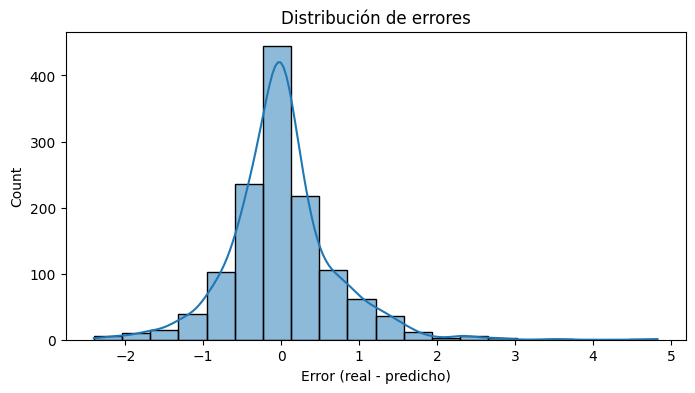

In [ ]:

errores = y_test - y_pred

plt.figure(figsize=(8,4))
sns.histplot(errores, bins=20, kde=True)
plt.title("Distribución de errores")
plt.xlabel("Error (real - predicho)")
plt.show()

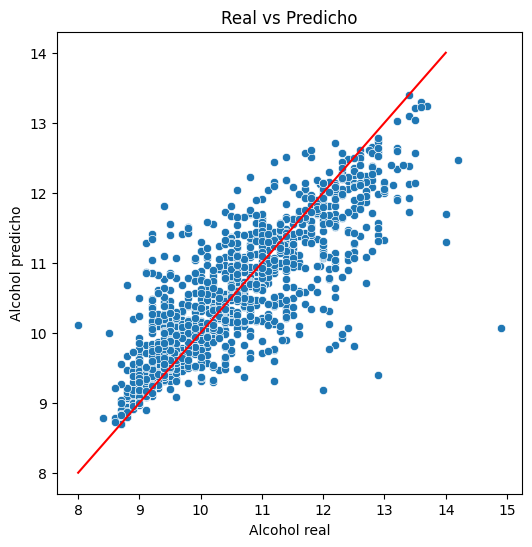

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Alcohol real")
plt.ylabel("Alcohol predicho")
plt.title("Real vs Predicho")
plt.plot([8,14], [8,14], color='red')
plt.show()